<a href="https://colab.research.google.com/github/Chandini-M555/E-Commerce_site/blob/main/Task_E_commerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#E-Commerce site
# Company scenario(Flipkart/Amazon)
# we are seeing drop in revenue find reason and suggest actions

In [ ]:
#importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#load the data
customers=pd.read_csv("/content/customers.csv")
orders=pd.read_csv("/content/orders.csv")
products=pd.read_csv("/content/products.csv")


In [ ]:
#Merging the data files
df=pd.merge(customers,orders,on="customer_id",how="inner")
df=pd.merge(df,products,on="product_id",how="inner")
df


,customer_id,customer_name,signup_date,order_id,product_id,order_date,city,quantity,product_name,category,price
0,101,Ravi,2023-11-10,1,201,2024-01-05,Hyderabad,1,Laptop,Electronics,70000
1,101,Ravi,2023-11-10,4,202,2024-02-12,Hyderabad,1,Mobile,Electronics,20000
2,101,Ravi,2023-11-10,11,201,2024-05-05,Hyderabad,1,Laptop,Electronics,70000
3,102,Sneha,2023-12-01,2,202,2024-01-06,Bangalore,2,Mobile,Electronics,20000
4,102,Sneha,2023-12-01,7,203,2024-03-15,Bangalore,1,Tablet,Electronics,15000
5,103,Amit,2023-12-15,3,203,2024-01-10,Chennai,1,Tablet,Electronics,15000
6,103,Amit,2023-12-15,12,205,2024-05-09,Chennai,1,Watch,Fashion,5000
7,104,Pooja,2024-01-05,5,204,2024-02-18,Bangalore,3,Shoes,Fashion,3000
8,104,Pooja,2024-01-05,13,202,2024-05-15,Bangalore,1,Mobile,Electronics,20000
9,105,Kiran,2024-01-20,6,201,2024-03-05,Chennai,1,Laptop,Electronics,70000


In [ ]:
#converting object data columns into date time columns
df["signup_date"]=pd.to_datetime(df["signup_date"])
df["order_date"]=pd.to_datetime(df["order_date"])
df

,customer_id,customer_name,signup_date,order_id,product_id,order_date,city,quantity,product_name,category,price
0,101,Ravi,2023-11-10,1,201,2024-01-05,Hyderabad,1,Laptop,Electronics,70000
1,101,Ravi,2023-11-10,4,202,2024-02-12,Hyderabad,1,Mobile,Electronics,20000
2,101,Ravi,2023-11-10,11,201,2024-05-05,Hyderabad,1,Laptop,Electronics,70000
3,102,Sneha,2023-12-01,2,202,2024-01-06,Bangalore,2,Mobile,Electronics,20000
4,102,Sneha,2023-12-01,7,203,2024-03-15,Bangalore,1,Tablet,Electronics,15000
5,103,Amit,2023-12-15,3,203,2024-01-10,Chennai,1,Tablet,Electronics,15000
6,103,Amit,2023-12-15,12,205,2024-05-09,Chennai,1,Watch,Fashion,5000
7,104,Pooja,2024-01-05,5,204,2024-02-18,Bangalore,3,Shoes,Fashion,3000
8,104,Pooja,2024-01-05,13,202,2024-05-15,Bangalore,1,Mobile,Electronics,20000
9,105,Kiran,2024-01-20,6,201,2024-03-05,Chennai,1,Laptop,Electronics,70000


In [ ]:
#creating new revenue column
#formula: revenue=price*quantity
df["revenue"]=df["price"]*df["quantity"]
df.head()

,customer_id,customer_name,signup_date,order_id,product_id,order_date,city,quantity,product_name,category,price,revenue
0,101,Ravi,2023-11-10,1,201,2024-01-05,Hyderabad,1,Laptop,Electronics,70000,70000
1,101,Ravi,2023-11-10,4,202,2024-02-12,Hyderabad,1,Mobile,Electronics,20000,20000
2,101,Ravi,2023-11-10,11,201,2024-05-05,Hyderabad,1,Laptop,Electronics,70000,70000
3,102,Sneha,2023-12-01,2,202,2024-01-06,Bangalore,2,Mobile,Electronics,20000,40000
4,102,Sneha,2023-12-01,7,203,2024-03-15,Bangalore,1,Tablet,Electronics,15000,15000


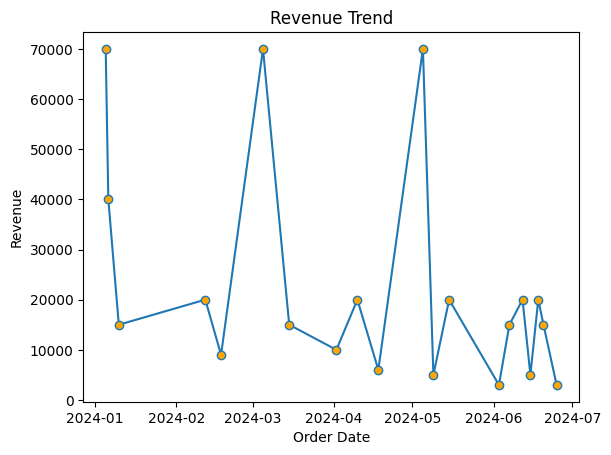

In [ ]:
#Revenue trend
revenue=df.groupby("order_date")["revenue"].sum()
revenue=pd.DataFrame(revenue)
revenue.reset_index(inplace=True)
#line plot
plt.plot(revenue["order_date"],revenue["revenue"],marker="o",mfc="orange")
plt.xlabel("Order Date")
plt.ylabel("Revenue")
plt.title("Revenue Trend")
plt.show()


The revenue is less in the last two months(mid may,june and july)

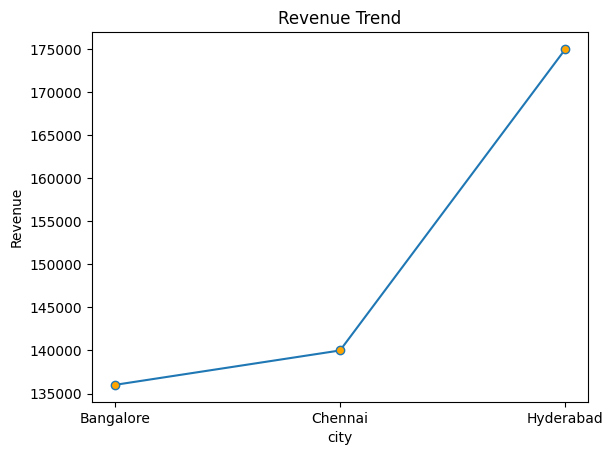

In [ ]:
#revenue by city
revenue=df.groupby("city")["revenue"].sum()
revenue=pd.DataFrame(revenue)
revenue.reset_index(inplace=True)
#line plot
plt.plot(revenue["city"],revenue["revenue"],marker="o",mfc="orange")
plt.xlabel("city")
plt.ylabel("Revenue")
plt.title("Revenue Trend")
plt.show()

The revenue is less in Banglore

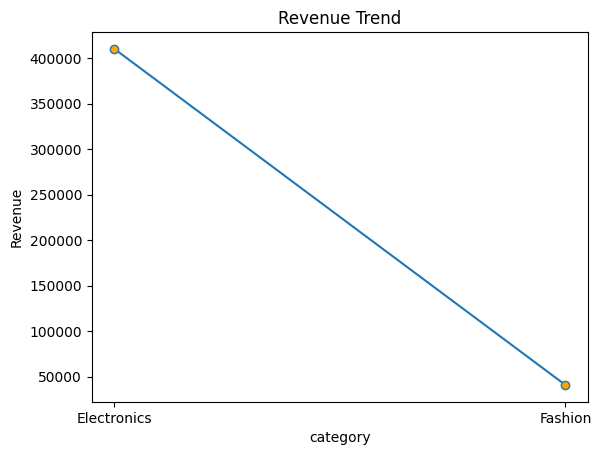

In [ ]:
#revenue by category
revenue=df.groupby("category")["revenue"].sum()
revenue=pd.DataFrame(revenue)
revenue.reset_index(inplace=True)
#line plot
plt.plot(revenue["category"],revenue["revenue"],marker="o",mfc="orange")
plt.xlabel("category")
plt.ylabel("Revenue")
plt.title("Revenue Trend")
plt.show()

The revenue is less in Fashion

In [ ]:
#count customers based on order_id
customers=df.groupby("customer_id")["order_id"].count()
customers

,order_id
customer_id,
101,3
102,2
103,2
104,2
105,1
106,1
107,1
108,1
109,1


Most of the customers are ordering less


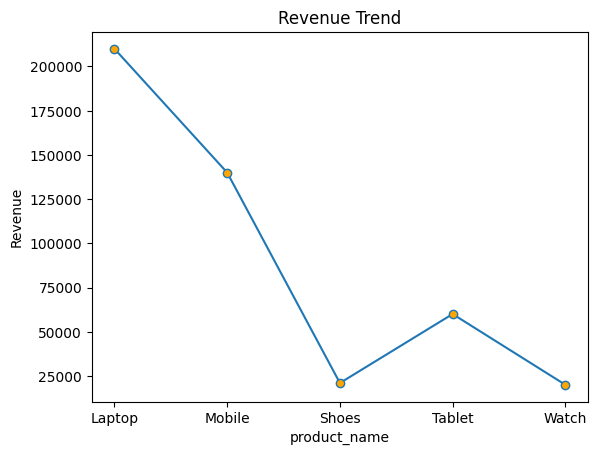

In [ ]:
#revenue by product name
revenue=df.groupby("product_name")["revenue"].sum()
revenue=pd.DataFrame(revenue)
revenue.reset_index(inplace=True)
#line plot
plt.plot(revenue["product_name"],revenue["revenue"],marker="o",mfc="orange")
plt.xlabel("product_name")
plt.ylabel("Revenue")
plt.title("Revenue Trend")
plt.show()

Revenue is very less for shoes and watch


**Insights:**
1.Revenue got dropped in last two months i.e,june and july

2.Banglore contributed more in revenue drop

3.Fashion category records less revenue

4.Repeated customers ordered less

5.Shoes and watch were less ordered

**Recommendations:**
1.Marketing should be done i Banglore

2.Coupons,discounts,loyalty programs for repeated customers

3.provide discounts for shoe and watch